In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
train = pd.read_csv("../data/processed/train_features.csv")
validation = pd.read_csv("../data/processed/validation_features.csv")
test = pd.read_csv("../data/processed/test_features.csv")

train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])
test["date"] = pd.to_datetime(test["date"])

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)

Train shape: (13104, 51)
Validation shape: (2808, 51)
Test shape: (2809, 51)


In [4]:
target_column = "target_energy"
excluded_columns = ["date", target_column]

X_train = train.drop(columns=excluded_columns)
y_train = train[target_column]

X_validation = validation.drop(columns=excluded_columns)
y_validation = validation[target_column]

X_test = test.drop(columns=excluded_columns)
y_test = test[target_column]

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

X_train: (13104, 49)
X_validation: (2808, 49)
X_test: (2809, 49)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_validation_scaled = scaler.transform(X_validation)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_validation_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Feature scaling completed.
Scaled training shape: (13104, 49)
Scaled validation shape: (2808, 49)
Scaled test shape: (2809, 49)


In [6]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [7]:
y_validation_pred_lr = linear_model.predict(X_validation_scaled)

print("Validation predictions generated.")
print("Number of predictions:", len(y_validation_pred_lr))

Validation predictions generated.
Number of predictions: 2808


In [8]:
lr_mae = mean_absolute_error(
    y_validation,
    y_validation_pred_lr
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        y_validation_pred_lr
    )
)

lr_r2 = r2_score(
    y_validation,
    y_validation_pred_lr
)

print("Linear Regression - Validation")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R²  :", lr_r2)

Linear Regression - Validation
MAE : 49.605282152989176
RMSE: 83.4351912282874
R²  : 0.13057882281495015


In [9]:
linear_result = {
    "Model": "Linear Regression",
    "MAE": lr_mae,
    "RMSE": lr_rmse,
    "R2": lr_r2
}

print(linear_result)

{'Model': 'Linear Regression', 'MAE': 49.605282152989176, 'RMSE': 83.4351912282874, 'R2': 0.13057882281495015}


In [10]:
model_results = pd.DataFrame([
    {
        "Model": "Persistence Baseline",
        "MAE": 50.434,
        "RMSE": 108.553,
        "R2": -0.472
    },
    {
        "Model": "24-Hour Lag Baseline",
        "MAE": 53.921,
        "RMSE": 113.437,
        "R2": -0.607
    },
    linear_result
])

model_results

,Model,MAE,RMSE,R2
0,Persistence Baseline,50.434000,108.553000,-0.472000
1,24-Hour Lag Baseline,53.921000,113.437000,-0.607000
2,Linear Regression,49.605282,83.435191,0.130579


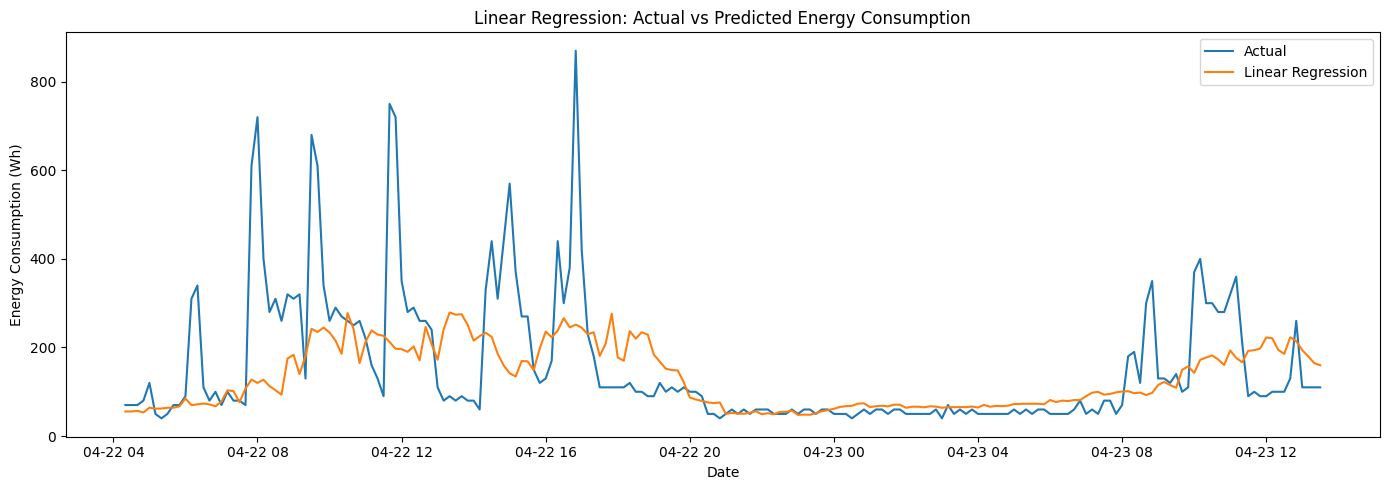

In [11]:
plot_start = 500
plot_end = 700

plt.figure(figsize=(14, 5))

plt.plot(
    validation["date"].iloc[plot_start:plot_end],
    y_validation.iloc[plot_start:plot_end],
    label="Actual"
)

plt.plot(
    validation["date"].iloc[plot_start:plot_end],
    y_validation_pred_lr[plot_start:plot_end],
    label="Linear Regression"
)

plt.title("Linear Regression: Actual vs Predicted Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (Wh)")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
from sklearn.ensemble import RandomForestRegressor

print("Random Forest imported successfully.")

Random Forest imported successfully.


In [13]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [14]:
y_validation_pred_rf = rf_model.predict(X_validation)

print("Random Forest validation predictions generated.")
print("Number of predictions:", len(y_validation_pred_rf))

Random Forest validation predictions generated.
Number of predictions: 2808


In [15]:
rf_mae = mean_absolute_error(
    y_validation,
    y_validation_pred_rf
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        y_validation_pred_rf
    )
)

rf_r2 = r2_score(
    y_validation,
    y_validation_pred_rf
)

print("Random Forest - Validation")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest - Validation
MAE : 60.471177208525084
RMSE: 97.80249245282921
R²  : -0.19462480625706835


In [16]:
rf_result = {
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "R2": rf_r2
}

print(rf_result)

{'Model': 'Random Forest', 'MAE': 60.471177208525084, 'RMSE': 97.80249245282921, 'R2': -0.19462480625706835}


In [17]:
model_results = pd.DataFrame([
    {
        "Model": "Persistence Baseline",
        "MAE": 50.434,
        "RMSE": 108.553,
        "R2": -0.472
    },
    {
        "Model": "24-Hour Lag Baseline",
        "MAE": 53.921,
        "RMSE": 113.437,
        "R2": -0.607
    },
    linear_result,
    rf_result
])

model_results

,Model,MAE,RMSE,R2
0,Persistence Baseline,50.434000,108.553000,-0.472000
1,24-Hour Lag Baseline,53.921000,113.437000,-0.607000
2,Linear Regression,49.605282,83.435191,0.130579
3,Random Forest,60.471177,97.802492,-0.194625


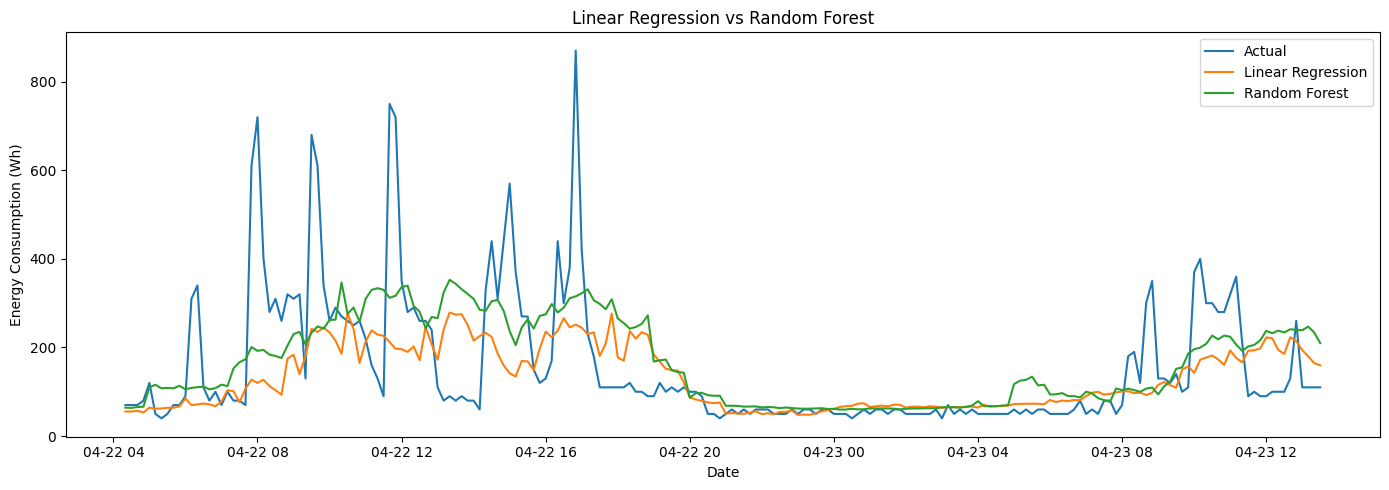

In [18]:
plot_start = 500
plot_end = 700

plt.figure(figsize=(14, 5))

plt.plot(
    validation["date"].iloc[plot_start:plot_end],
    y_validation.iloc[plot_start:plot_end],
    label="Actual"
)

plt.plot(
    validation["date"].iloc[plot_start:plot_end],
    y_validation_pred_lr[plot_start:plot_end],
    label="Linear Regression"
)

plt.plot(
    validation["date"].iloc[plot_start:plot_end],
    y_validation_pred_rf[plot_start:plot_end],
    label="Random Forest"
)

plt.title("Linear Regression vs Random Forest")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (Wh)")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
46,rolling_std_2hours,0.133813
43,rolling_mean_1hour,0.070165
33,hour_cos,0.064863
0,Appliances,0.034973
32,hour_sin,0.033431
45,rolling_mean_2hours,0.029201
21,Press_mm_hg,0.026318
10,T5,0.023909
11,RH_5,0.023272
6,T3,0.021592


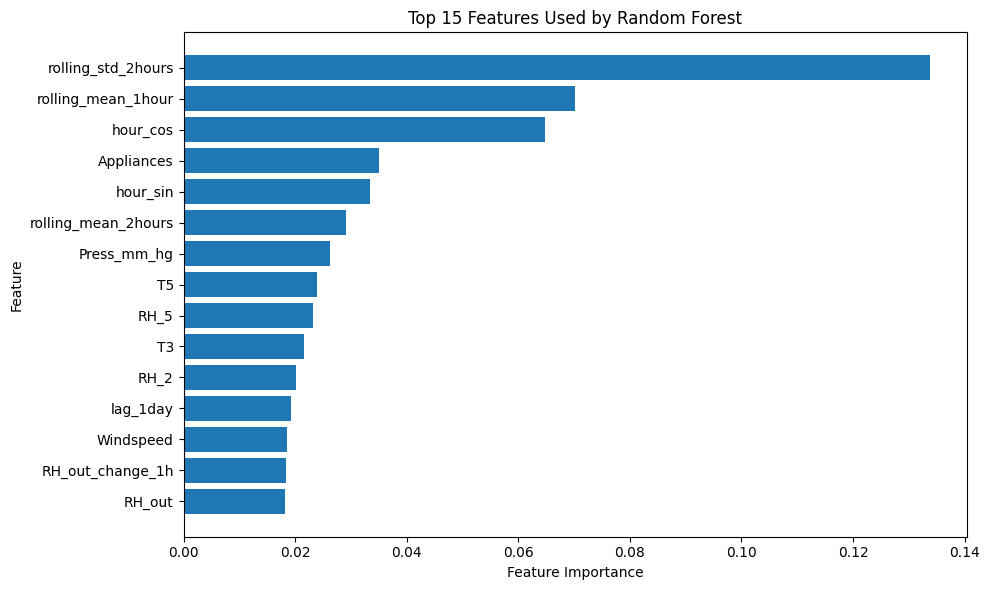

In [20]:
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Used by Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [21]:
from sklearn.ensemble import GradientBoostingRegressor

print("Gradient Boosting imported successfully.")

Gradient Boosting imported successfully.


In [22]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


In [23]:
y_validation_pred_gb = gb_model.predict(X_validation)

print("Gradient Boosting validation predictions generated.")
print("Number of predictions:", len(y_validation_pred_gb))

Gradient Boosting validation predictions generated.
Number of predictions: 2808


In [24]:
gb_mae = mean_absolute_error(
    y_validation,
    y_validation_pred_gb
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        y_validation_pred_gb
    )
)

gb_r2 = r2_score(
    y_validation,
    y_validation_pred_gb
)

print("Gradient Boosting - Validation")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

Gradient Boosting - Validation
MAE : 53.47287130850566
RMSE: 89.89255645555937
R²  : -0.009204425157842033


In [25]:
gb_result = {
    "Model": "Gradient Boosting",
    "MAE": gb_mae,
    "RMSE": gb_rmse,
    "R2": gb_r2
}

print(gb_result)

{'Model': 'Gradient Boosting', 'MAE': 53.47287130850566, 'RMSE': 89.89255645555937, 'R2': -0.009204425157842033}


In [26]:
model_results = pd.DataFrame([
    {
        "Model": "Persistence Baseline",
        "MAE": 50.434,
        "RMSE": 108.553,
        "R2": -0.472
    },
    {
        "Model": "24-Hour Lag Baseline",
        "MAE": 53.921,
        "RMSE": 113.437,
        "R2": -0.607
    },
    linear_result,
    rf_result,
    gb_result
])

model_results

,Model,MAE,RMSE,R2
0,Persistence Baseline,50.434000,108.553000,-0.472000
1,24-Hour Lag Baseline,53.921000,113.437000,-0.607000
2,Linear Regression,49.605282,83.435191,0.130579
3,Random Forest,60.471177,97.802492,-0.194625
4,Gradient Boosting,53.472871,89.892556,-0.009204


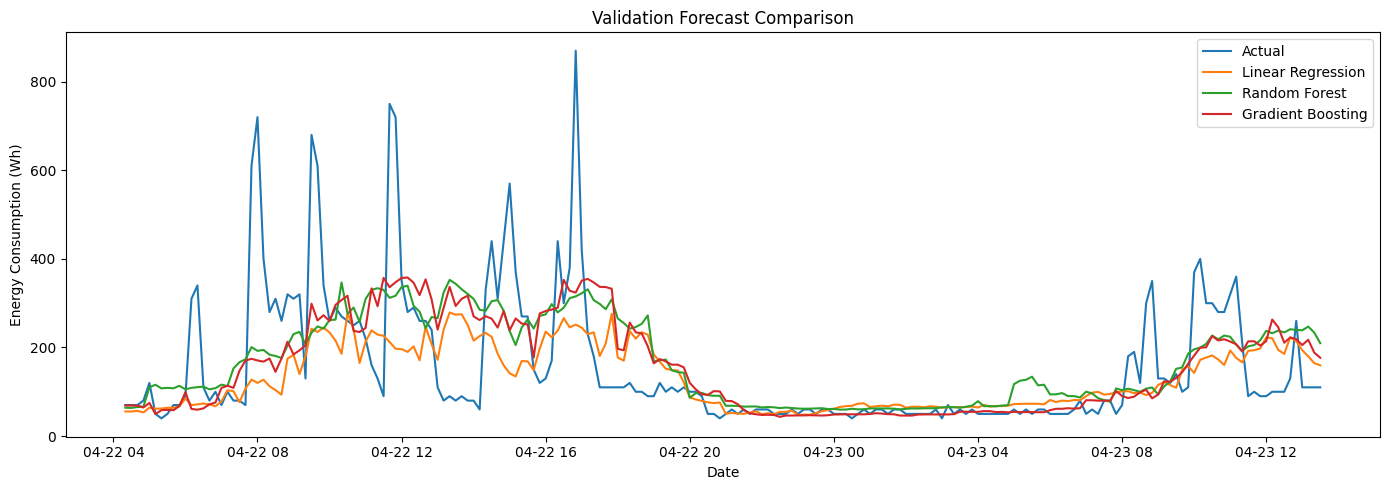

In [27]:
plot_start = 500
plot_end = 700

plt.figure(figsize=(14, 5))

plt.plot(
    validation["date"].iloc[plot_start:plot_end],
    y_validation.iloc[plot_start:plot_end],
    label="Actual"
)

plt.plot(
    validation["date"].iloc[plot_start:plot_end],
    y_validation_pred_lr[plot_start:plot_end],
    label="Linear Regression"
)

plt.plot(
    validation["date"].iloc[plot_start:plot_end],
    y_validation_pred_rf[plot_start:plot_end],
    label="Random Forest"
)

plt.plot(
    validation["date"].iloc[plot_start:plot_end],
    y_validation_pred_gb[plot_start:plot_end],
    label="Gradient Boosting"
)

plt.title("Validation Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (Wh)")
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
try:
    import xgboost as xgb
    print("XGBoost version:", xgb.__version__)
except ImportError:
    print("XGBoost is not installed.")

XGBoost version: 3.2.0


In [29]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [30]:
y_validation_pred_xgb = xgb_model.predict(X_validation)

print("XGBoost validation predictions generated.")
print("Number of predictions:", len(y_validation_pred_xgb))

XGBoost validation predictions generated.
Number of predictions: 2808


In [31]:
xgb_mae = mean_absolute_error(
    y_validation,
    y_validation_pred_xgb
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        y_validation_pred_xgb
    )
)

xgb_r2 = r2_score(
    y_validation,
    y_validation_pred_xgb
)

print("XGBoost - Validation")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBoost - Validation
MAE : 66.56097971679817
RMSE: 109.57686412899959
R²  : -0.49957923629544543


In [32]:
xgb_result = {
    "Model": "XGBoost",
    "MAE": xgb_mae,
    "RMSE": xgb_rmse,
    "R2": xgb_r2
}

print(xgb_result)

{'Model': 'XGBoost', 'MAE': 66.56097971679817, 'RMSE': 109.57686412899959, 'R2': -0.49957923629544543}


In [33]:
model_results = pd.DataFrame([
    {
        "Model": "Persistence Baseline",
        "MAE": 50.434,
        "RMSE": 108.553,
        "R2": -0.472
    },
    {
        "Model": "24-Hour Lag Baseline",
        "MAE": 53.921,
        "RMSE": 113.437,
        "R2": -0.607
    },
    linear_result,
    rf_result,
    gb_result,
    xgb_result
])

model_results

,Model,MAE,RMSE,R2
0,Persistence Baseline,50.434000,108.553000,-0.472000
1,24-Hour Lag Baseline,53.921000,113.437000,-0.607000
2,Linear Regression,49.605282,83.435191,0.130579
3,Random Forest,60.471177,97.802492,-0.194625
4,Gradient Boosting,53.472871,89.892556,-0.009204
5,XGBoost,66.560980,109.576864,-0.499579


In [ ]:
weather_features = [
    "T_out",
    "RH_out",
    "Windspeed",
    "Visibility",
    "Press_mm_hg",
    "Tdewpoint",
    "T_out_change_1h",
    "RH_out_change_1h"
]

features_without_weather = [
    col for col in X_train.columns
    if col not in weather_features
]

X_train_no_weather = X_train[features_without_weather]
X_validation_no_weather = X_validation[features_without_weather]

X_train_with_weather = X_train.copy()
X_validation_with_weather = X_validation.copy()

print("Features without weather:", X_train_no_weather.shape[1])
print("Features with weather:", X_train_with_weather.shape[1])

Features without weather: 41
Features with weather: 49


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


scaler_no_weather = StandardScaler()

X_train_no_weather_scaled = scaler_no_weather.fit_transform(X_train_no_weather)
X_validation_no_weather_scaled = scaler_no_weather.transform(X_validation_no_weather)

lr_no_weather = LinearRegression()
lr_no_weather.fit(X_train_no_weather_scaled, y_train)

y_validation_pred_no_weather = lr_no_weather.predict(
    X_validation_no_weather_scaled
)

mae_no_weather = mean_absolute_error(
    y_validation, y_validation_pred_no_weather
)

rmse_no_weather = np.sqrt(
    mean_squared_error(y_validation, y_validation_pred_no_weather)
)

r2_no_weather = r2_score(
    y_validation, y_validation_pred_no_weather
)



scaler_with_weather = StandardScaler()

X_train_with_weather_scaled = scaler_with_weather.fit_transform(
    X_train_with_weather
)

X_validation_with_weather_scaled = scaler_with_weather.transform(
    X_validation_with_weather
)

lr_with_weather = LinearRegression()
lr_with_weather.fit(
    X_train_with_weather_scaled,
    y_train
)

y_validation_pred_with_weather = lr_with_weather.predict(
    X_validation_with_weather_scaled
)

mae_with_weather = mean_absolute_error(
    y_validation, y_validation_pred_with_weather
)

rmse_with_weather = np.sqrt(
    mean_squared_error(y_validation, y_validation_pred_with_weather)
)

r2_with_weather = r2_score(
    y_validation, y_validation_pred_with_weather
)



weather_comparison = pd.DataFrame({
    "Feature Set": [
        "Without Weather",
        "With Weather"
    ],
    "MAE": [
        mae_no_weather,
        mae_with_weather
    ],
    "RMSE": [
        rmse_no_weather,
        rmse_with_weather
    ],
    "R2": [
        r2_no_weather,
        r2_with_weather
    ]
})

weather_comparison

,Feature Set,MAE,RMSE,R2
0,Without Weather,49.253682,83.286906,0.133666
1,With Weather,49.605282,83.435191,0.130579


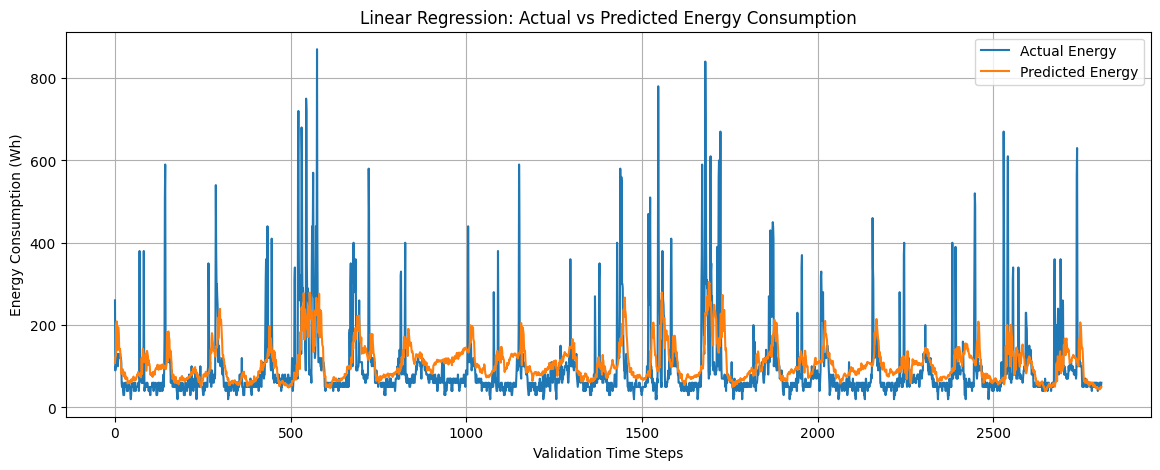

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    y_validation.values,
    label="Actual Energy"
)

plt.plot(
    y_validation_pred_with_weather,
    label="Predicted Energy"
)

plt.title("Linear Regression: Actual vs Predicted Energy Consumption")
plt.xlabel("Validation Time Steps")
plt.ylabel("Energy Consumption (Wh)")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
# Calculate residuals
residuals = y_validation.values - y_validation_pred_with_weather

print("Mean Residual:", residuals.mean())
print("Maximum Positive Residual:", residuals.max())
print("Maximum Negative Residual:", residuals.min())

Mean Residual: -13.084351526905078
Maximum Positive Residual: 688.6659197613222
Maximum Negative Residual: -234.96492045263597


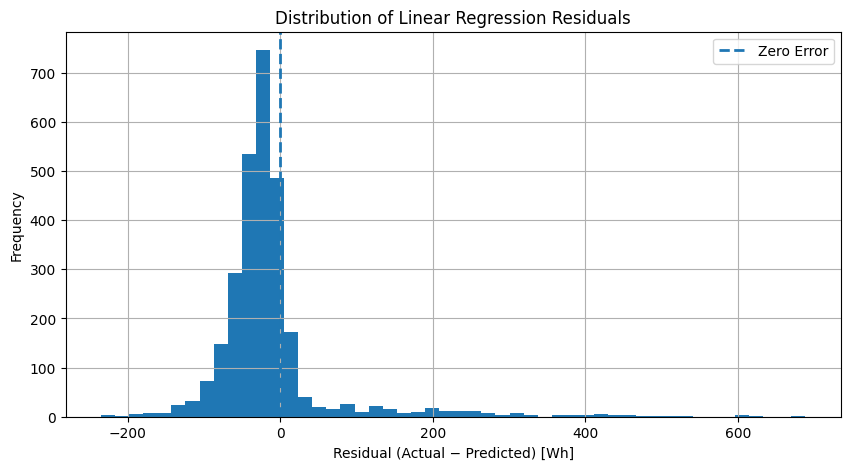

In [38]:
plt.figure(figsize=(10, 5))

plt.hist(
    residuals,
    bins=50
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Zero Error"
)

plt.title("Distribution of Linear Regression Residuals")
plt.xlabel("Residual (Actual − Predicted) [Wh]")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
validation_data = pd.read_csv(
    "../data/processed/validation_features.csv"
)

validation_data["date"] = pd.to_datetime(validation_data["date"])

validation_analysis = pd.DataFrame({
    "date": validation_data["date"].values,
    "actual": y_validation.values,
    "predicted": y_validation_pred_with_weather
})

validation_analysis["hour"] = validation_analysis["date"].dt.hour

validation_analysis["absolute_error"] = (
    validation_analysis["actual"] -
    validation_analysis["predicted"]
).abs()

hourly_error = (
    validation_analysis
    .groupby("hour")["absolute_error"]
    .mean()
)

hourly_error

hour
0      22.095384
1      21.628639
2      22.799299
3      21.512319
4      29.567522
5      27.408536
6      78.932721
7      60.855252
8      75.866307
9      62.411390
10     62.571796
11     68.529230
12     61.241954
13     65.027913
14     59.404182
15     70.708441
16    106.159192
17     93.223155
18     59.479184
19     38.119576
20     29.835276
21     26.878251
22     20.038994
23     16.424935
Name: absolute_error, dtype: float64

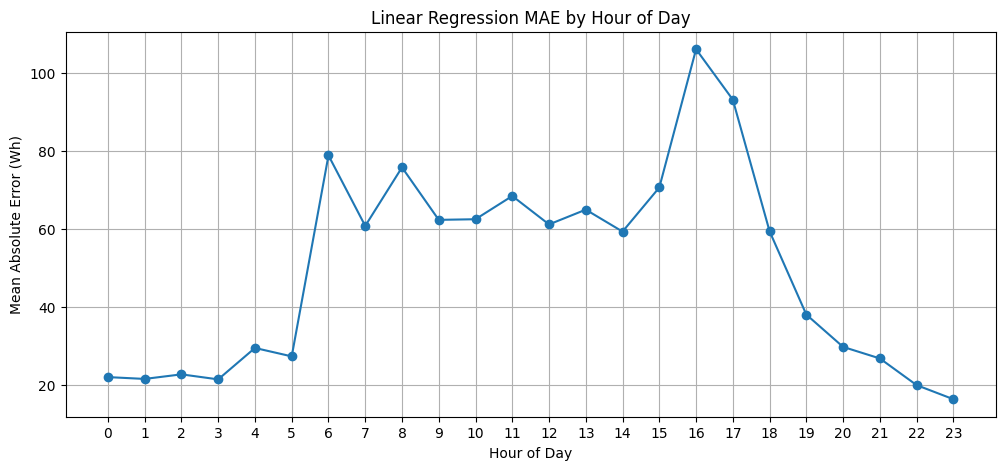

In [40]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_error.index,
    hourly_error.values,
    marker="o"
)

plt.title("Linear Regression MAE by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Absolute Error (Wh)")
plt.xticks(range(24))
plt.grid(True)

plt.show()

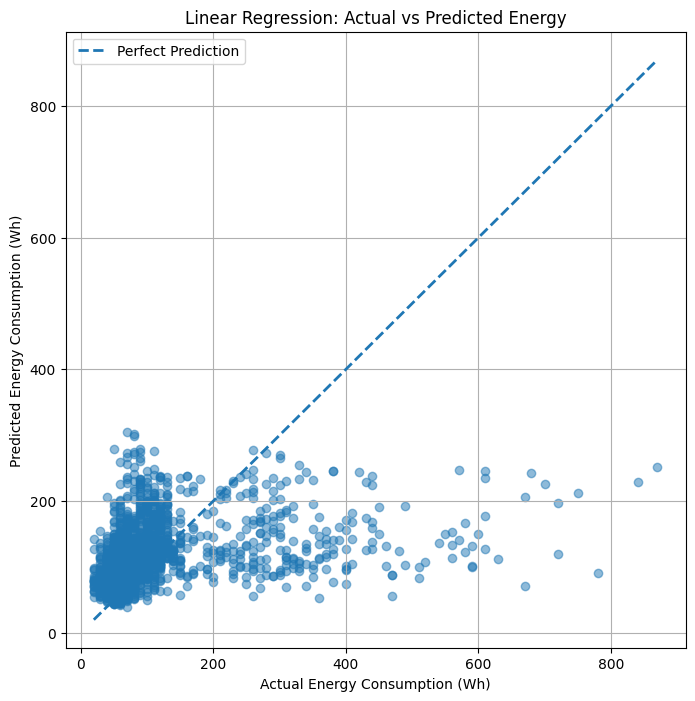

In [ ]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_validation,
    y_validation_pred_with_weather,
    alpha=0.5
)

min_value = min(y_validation.min(), y_validation_pred_with_weather.min())
max_value = max(y_validation.max(), y_validation_pred_with_weather.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Linear Regression: Actual vs Predicted Energy")
plt.xlabel("Actual Energy Consumption (Wh)")
plt.ylabel("Predicted Energy Consumption (Wh)")
plt.legend()
plt.grid(True)

plt.show()

In [42]:
from sklearn.linear_model import Ridge

# Train Ridge Regression
ridge_model = Ridge(alpha=10.0)

ridge_model.fit(
    X_train_scaled,
    y_train
)

# Validation predictions
y_validation_pred_ridge = ridge_model.predict(
    X_validation_scaled
)

# Evaluation
ridge_mae = mean_absolute_error(
    y_validation,
    y_validation_pred_ridge
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        y_validation_pred_ridge
    )
)

ridge_r2 = r2_score(
    y_validation,
    y_validation_pred_ridge
)

print("Ridge Regression")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

Ridge Regression
MAE : 47.681157657511655
RMSE: 82.95261490685591
R²  : 0.1406069350786221


In [ ]:
alpha_values = [0.01, 0.1, 1, 10, 100, 1000]

ridge_tuning_results = []

for alpha in alpha_values:

    model = Ridge(alpha=alpha)

    model.fit(
        X_train_scaled,
        y_train
    )

    predictions = model.predict(
        X_validation_scaled
    )

    mae = mean_absolute_error(
        y_validation,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            predictions
        )
    )

    r2 = r2_score(
        y_validation,
        predictions
    )

    ridge_tuning_results.append({
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

ridge_tuning_results = pd.DataFrame(
    ridge_tuning_results
)

ridge_tuning_results

,Alpha,MAE,RMSE,R2
0,0.01,49.593142,83.432600,0.130633
1,0.10,49.457228,83.396227,0.131391
2,1.00,48.717592,83.207559,0.135316
3,10.00,47.681158,82.952615,0.140607
4,100.00,46.630457,82.666019,0.146535
5,1000.00,43.581765,81.836615,0.163575


In [44]:
best_ridge_result = ridge_tuning_results.loc[
    ridge_tuning_results["MAE"].idxmin()
]

print("Best Ridge Configuration:")
print(best_ridge_result)

Best Ridge Configuration:
Alpha    1000.000000
MAE        43.581765
RMSE       81.836615
R2          0.163575
Name: 5, dtype: float64


In [ ]:
fine_alpha_values = [
    300,
    500,
    750,
    1000,
    1500,
    2000,
    3000,
    5000
]

fine_ridge_results = []

for alpha in fine_alpha_values:

    model = Ridge(alpha=alpha)

    model.fit(
        X_train_scaled,
        y_train
    )

    predictions = model.predict(
        X_validation_scaled
    )

    mae = mean_absolute_error(
        y_validation,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            predictions
        )
    )

    r2 = r2_score(
        y_validation,
        predictions
    )

    fine_ridge_results.append({
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

fine_ridge_results = pd.DataFrame(
    fine_ridge_results
)

fine_ridge_results

,Alpha,MAE,RMSE,R2
0,300,45.487772,82.327961,0.153501
1,500,44.708767,82.116136,0.157851
2,750,44.038953,81.946035,0.161337
3,1000,43.581765,81.836615,0.163575
4,1500,43.016993,81.714317,0.166073
5,2000,42.710644,81.658596,0.167210
6,3000,42.456853,81.633379,0.167724
7,5000,42.465715,81.700485,0.166355


In [46]:
best_fine_ridge = fine_ridge_results.loc[
    fine_ridge_results["MAE"].idxmin()
]

print("Best Fine-Tuned Ridge Configuration:")
print(best_fine_ridge)

Best Fine-Tuned Ridge Configuration:
Alpha    3000.000000
MAE        42.456853
RMSE       81.633379
R2          0.167724
Name: 6, dtype: float64


In [ ]:
final_alpha_values = [
    2000,
    2500,
    2750,
    3000,
    3250,
    3500,
    4000
]

final_ridge_results = []

for alpha in final_alpha_values:

    model = Ridge(alpha=alpha)

    model.fit(
        X_train_scaled,
        y_train
    )

    predictions = model.predict(
        X_validation_scaled
    )

    mae = mean_absolute_error(
        y_validation,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            predictions
        )
    )

    r2 = r2_score(
        y_validation,
        predictions
    )

    final_ridge_results.append({
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

final_ridge_results = pd.DataFrame(
    final_ridge_results
)

final_ridge_results

,Alpha,MAE,RMSE,R2
0,2000,42.710644,81.658596,0.167210
1,2500,42.542977,81.636515,0.167660
2,2750,42.492015,81.633154,0.167729
3,3000,42.456853,81.633379,0.167724
4,3250,42.433411,81.636415,0.167662
5,3500,42.419499,81.641676,0.167555
6,4000,42.414452,81.657175,0.167239


In [48]:
best_final_ridge = final_ridge_results.loc[
    final_ridge_results["MAE"].idxmin()
]

print("Final Ridge Selection:")
print(best_final_ridge)

Final Ridge Selection:
Alpha    4000.000000
MAE        42.414452
RMSE       81.657175
R2          0.167239
Name: 6, dtype: float64


In [ ]:
best_alpha = 4000

final_ridge_model = Ridge(alpha=best_alpha)

final_ridge_model.fit(
    X_train_scaled,
    y_train
)


y_validation_pred_final_ridge = final_ridge_model.predict(
    X_validation_scaled
)

final_ridge_mae = mean_absolute_error(
    y_validation,
    y_validation_pred_final_ridge
)

final_ridge_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        y_validation_pred_final_ridge
    )
)

final_ridge_r2 = r2_score(
    y_validation,
    y_validation_pred_final_ridge
)

print("Final Tuned Ridge Regression")
print("Alpha:", best_alpha)
print("MAE :", final_ridge_mae)
print("RMSE:", final_ridge_rmse)
print("R²  :", final_ridge_r2)

Final Tuned Ridge Regression
Alpha: 4000
MAE : 42.414451856608906
RMSE: 81.65717464536249
R²  : 0.16723899340842074


In [ ]:

final_model_results = pd.DataFrame([
    {
        "Model": "Persistence Baseline",
        "MAE": 50.434000,
        "RMSE": 108.553000,
        "R2": -0.472000
    },
    {
        "Model": "24-Hour Lag Baseline",
        "MAE": 53.921000,
        "RMSE": 113.437000,
        "R2": -0.607000
    },
    {
        "Model": "Linear Regression",
        "MAE": 49.605282,
        "RMSE": 83.435191,
        "R2": 0.130579
    },
    {
        "Model": "Random Forest",
        "MAE": 60.471777,
        "RMSE": 97.802492,
        "R2": -0.194625
    },
    {
        "Model": "Gradient Boosting",
        "MAE": 53.472871,
        "RMSE": 89.892556,
        "R2": -0.009204
    },
    {
        "Model": "XGBoost",
        "MAE": 66.560980,
        "RMSE": 109.576864,
        "R2": -0.499579
    },
    {
        "Model": "Tuned Ridge Regression",
        "MAE": final_ridge_mae,
        "RMSE": final_ridge_rmse,
        "R2": final_ridge_r2
    }
])

# Sort by MAE
final_model_results = final_model_results.sort_values(
    by="MAE"
).reset_index(drop=True)

final_model_results

,Model,MAE,RMSE,R2
0,Tuned Ridge Regression,42.414452,81.657175,0.167239
1,Linear Regression,49.605282,83.435191,0.130579
2,Persistence Baseline,50.434000,108.553000,-0.472000
3,Gradient Boosting,53.472871,89.892556,-0.009204
4,24-Hour Lag Baseline,53.921000,113.437000,-0.607000
5,Random Forest,60.471777,97.802492,-0.194625
6,XGBoost,66.560980,109.576864,-0.499579


In [ ]:
X_development = pd.concat(
    [X_train, X_validation],
    axis=0
)

y_development = pd.concat(
    [y_train, y_validation],
    axis=0
)

print("Development data shape:", X_development.shape)
print("Test data shape:", X_test.shape)




final_scaler = StandardScaler()

X_development_scaled = final_scaler.fit_transform(
    X_development
)

X_test_scaled_final = final_scaler.transform(
    X_test
)



final_model = Ridge(alpha=4000)

final_model.fit(
    X_development_scaled,
    y_development
)




y_test_pred = final_model.predict(
    X_test_scaled_final
)



final_test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

final_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

final_test_r2 = r2_score(
    y_test,
    y_test_pred
)


print("\nFinal Test Performance")
print("----------------------")
print("Model: Ridge Regression")
print("Alpha:", 4000)
print("MAE :", final_test_mae)
print("RMSE:", final_test_rmse)
print("R²  :", final_test_r2)

Development data shape: (15912, 49)
Test data shape: (2809, 49)

Final Test Performance
----------------------
Model: Ridge Regression
Alpha: 4000
MAE : 39.628020503054664
RMSE: 80.08171924899472
R²  : 0.23298421419625803


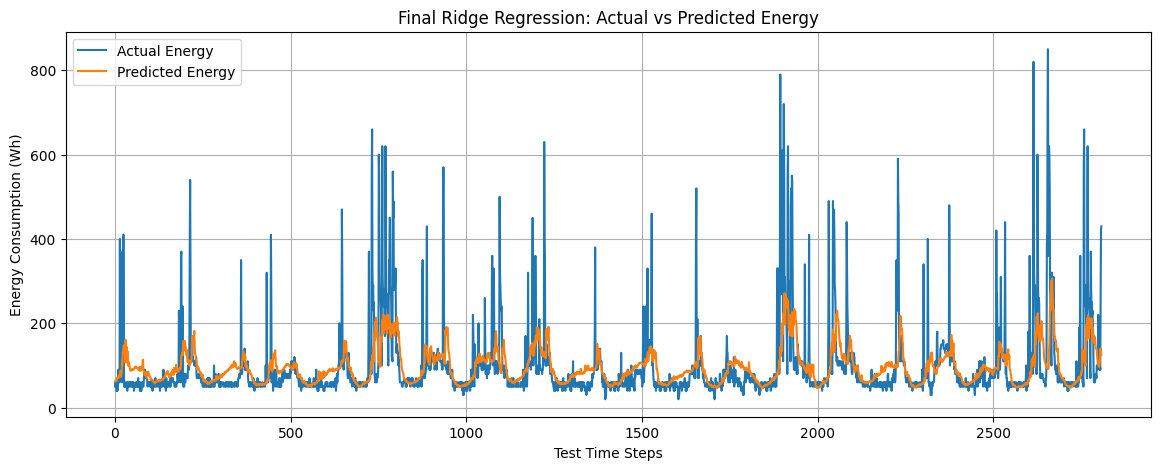

In [52]:
plt.figure(figsize=(14, 5))

plt.plot(
    y_test.values,
    label="Actual Energy"
)

plt.plot(
    y_test_pred,
    label="Predicted Energy"
)

plt.title(
    "Final Ridge Regression: Actual vs Predicted Energy"
)

plt.xlabel("Test Time Steps")
plt.ylabel("Energy Consumption (Wh)")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:

test_residuals = y_test.values - y_test_pred

print("Mean Test Residual:", test_residuals.mean())
print("Maximum Positive Residual:", test_residuals.max())
print("Maximum Negative Residual:", test_residuals.min())

Mean Test Residual: 1.9659749228154952
Maximum Positive Residual: 756.8549526350002
Maximum Negative Residual: -186.9100198614526


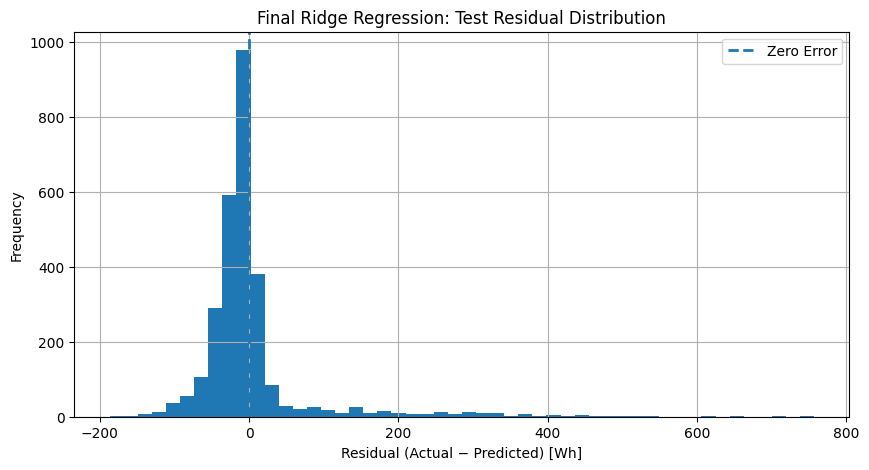

In [54]:
plt.figure(figsize=(10, 5))

plt.hist(
    test_residuals,
    bins=50
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Zero Error"
)

plt.title("Final Ridge Regression: Test Residual Distribution")
plt.xlabel("Residual (Actual − Predicted) [Wh]")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:


feature_coefficients = pd.DataFrame({
    "Feature": X_development.columns,
    "Coefficient": final_model.coef_
})


feature_coefficients["Absolute_Coefficient"] = (
    feature_coefficients["Coefficient"].abs()
)


feature_coefficients = feature_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

feature_coefficients.head(15)

,Feature,Coefficient,Absolute_Coefficient
0,hour_cos,-15.128696,15.128696
1,Appliances,9.864762,9.864762
2,rolling_std_2hours,8.211252,8.211252
3,rolling_mean_2hours,7.604668,7.604668
4,rolling_mean_1hour,6.897969,6.897969
5,lag_30min,5.639707,5.639707
6,lag_1hour,5.560898,5.560898
7,RH_9,5.223803,5.223803
8,hour_sin,-5.132162,5.132162
9,T2,-3.934277,3.934277


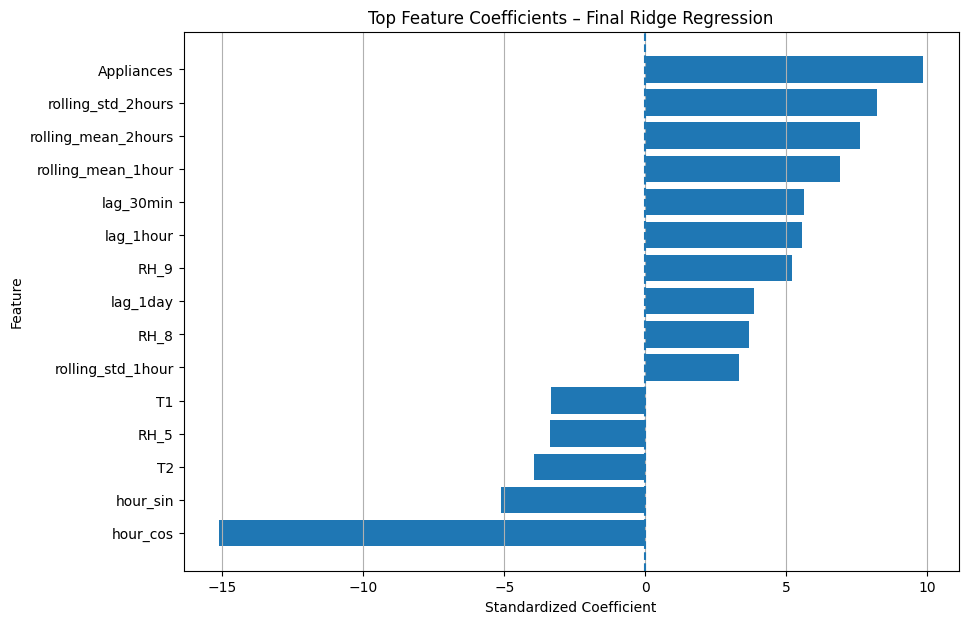

In [ ]:

top_coefficients = feature_coefficients.head(15).copy()


top_coefficients = top_coefficients.sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.title("Top Feature Coefficients – Final Ridge Regression")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")

plt.grid(True, axis="x")

plt.show()

In [57]:
import os
import joblib


os.makedirs("../models", exist_ok=True)


joblib.dump(
    final_model,
    "../models/final_ridge_model.pkl"
)


joblib.dump(
    final_scaler,
    "../models/final_scaler.pkl"
)


joblib.dump(
    list(X_development.columns),
    "../models/model_features.pkl"
)

print("Final model and preprocessing artifacts saved successfully.")

Final model and preprocessing artifacts saved successfully.


In [58]:
print("Saved files:")

for filename in os.listdir("../models"):
    print("-", filename)

Saved files:
- final_ridge_model.pkl
- final_scaler.pkl
- model_features.pkl


In [59]:
import joblib
import pandas as pd
import numpy as np

# Load saved artifacts
loaded_model = joblib.load(
    "../models/final_ridge_model.pkl"
)

loaded_scaler = joblib.load(
    "../models/final_scaler.pkl"
)

model_features = joblib.load(
    "../models/model_features.pkl"
)

print("Model loaded successfully.")
print("Scaler loaded successfully.")
print("Number of model features:", len(model_features))
print("First 10 features:")
print(model_features[:10])

Model loaded successfully.
Scaler loaded successfully.
Number of model features: 49
First 10 features:
['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4']


In [60]:
print("Feature configuration verification")
print("----------------------------------")

print("Expected number of features:", len(model_features))
print("Development feature count:", X_development.shape[1])
print("Feature order matches:",
      list(X_development.columns) == model_features)

Feature configuration verification
----------------------------------
Expected number of features: 49
Development feature count: 49
Feature order matches: True


In [61]:
def predict_energy_consumption(feature_data):
    """
    Predict energy consumption one hour ahead.

    Parameters
    ----------
    feature_data : pandas.DataFrame
        DataFrame containing the 49 features required by the final model.

    Returns
    -------
    numpy.ndarray
        Predicted energy consumption in Wh.
    """

    
    missing_features = [
        feature for feature in model_features
        if feature not in feature_data.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing required features: {missing_features}"
        )

    
    feature_data = feature_data[model_features]

    
    feature_data_scaled = loaded_scaler.transform(
        feature_data
    )

   
    prediction = loaded_model.predict(
        feature_data_scaled
    )

    return prediction

In [62]:
sample_input = X_test.iloc[[0]]

sample_prediction = predict_energy_consumption(
    sample_input
)

print("Predicted energy consumption:", sample_prediction[0], "Wh")
print("Actual energy consumption:", y_test.iloc[0], "Wh")
print(
    "Absolute error:",
    abs(y_test.iloc[0] - sample_prediction[0]),
    "Wh"
)

Predicted energy consumption: 62.42278653961063 Wh
Actual energy consumption: 50.0 Wh
Absolute error: 12.422786539610627 Wh


In [63]:
def create_forecast_features(raw_data):
    """
    Create the 49 model features required for a 1-hour-ahead forecast.
    """

    data = raw_data.copy()

    # Convert date and sort chronologically
    data["date"] = pd.to_datetime(data["date"])
    data = data.sort_values("date").reset_index(drop=True)

    # Remove redundant random variables
    data = data.drop(
        columns=["rv1", "rv2"],
        errors="ignore"
    )



    data["hour"] = data["date"].dt.hour
    data["day"] = data["date"].dt.day
    data["month"] = data["date"].dt.month
    data["day_of_week"] = data["date"].dt.dayofweek
    data["is_weekend"] = (
        data["day_of_week"] >= 5
    ).astype(int)

    data["week_of_year"] = (
        data["date"].dt.isocalendar().week.astype(int)
    )

    data["hour_sin"] = np.sin(
        2 * np.pi * data["hour"] / 24
    )

    data["hour_cos"] = np.cos(
        2 * np.pi * data["hour"] / 24
    )



    data["lag_10min"] = data["Appliances"].shift(1)
    data["lag_20min"] = data["Appliances"].shift(2)
    data["lag_30min"] = data["Appliances"].shift(3)
    data["lag_1hour"] = data["Appliances"].shift(6)
    data["lag_2hours"] = data["Appliances"].shift(12)
    data["lag_1day"] = data["Appliances"].shift(144)
    data["lag_1week"] = data["Appliances"].shift(1008)


    past_consumption = data["Appliances"].shift(1)

    data["rolling_mean_30min"] = (
        past_consumption.rolling(3).mean()
    )

    data["rolling_std_30min"] = (
        past_consumption.rolling(3).std()
    )

    data["rolling_mean_1hour"] = (
        past_consumption.rolling(6).mean()
    )

    data["rolling_std_1hour"] = (
        past_consumption.rolling(6).std()
    )

    data["rolling_mean_2hours"] = (
        past_consumption.rolling(12).mean()
    )

    data["rolling_std_2hours"] = (
        past_consumption.rolling(12).std()
    )



    data["T_out_change_1h"] = (
        data["T_out"] -
        data["T_out"].shift(6)
    )

    data["RH_out_change_1h"] = (
        data["RH_out"] -
        data["RH_out"].shift(6)
    )



    data = data.dropna().reset_index(drop=True)


    missing_features = [
        feature for feature in model_features
        if feature not in data.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing model features: {missing_features}"
        )

    return data[model_features]

In [64]:
raw_data = pd.read_csv(
    "../data/energydata_complete.csv"
)

forecast_features = create_forecast_features(
    raw_data
)

print(
    "Generated feature shape:",
    forecast_features.shape
)

print(
    "Expected feature count:",
    len(model_features)
)

print(
    "Feature order matches:",
    list(forecast_features.columns) == model_features
)

Generated feature shape: (18727, 49)
Expected feature count: 49
Feature order matches: True


In [65]:
forecast_features = create_forecast_features(raw_data)

latest_features = forecast_features.iloc[[-1]]

latest_features_scaled = loaded_scaler.transform(
    latest_features
)

forecast_value = loaded_model.predict(
    latest_features_scaled
)[0]

latest_timestamp = pd.to_datetime(
    raw_data["date"]
).max()

forecast_timestamp = latest_timestamp + pd.Timedelta(hours=1)

print("Energy Consumption Forecast")
print("---------------------------")
print("Latest available time :", latest_timestamp)
print("Forecast time          :", forecast_timestamp)
print("Forecast horizon       : 1 hour")
print(
    "Predicted consumption  :",
    round(forecast_value, 2),
    "Wh"
)

Energy Consumption Forecast
---------------------------
Latest available time : 2016-05-27 18:00:00
Forecast time          : 2016-05-27 19:00:00
Forecast horizon       : 1 hour
Predicted consumption  : 153.16 Wh


In [66]:
latest_consumption = raw_data.sort_values(
    "date"
)["Appliances"].iloc[-1]

change = forecast_value - latest_consumption

print("\nForecast Interpretation")
print("-----------------------")
print(
    "Current consumption:",
    round(latest_consumption, 2),
    "Wh"
)

print(
    "Forecast consumption:",
    round(forecast_value, 2),
    "Wh"
)

print(
    "Expected change:",
    round(change, 2),
    "Wh"
)

if change > 0:
    print("Expected trend: Increase")
elif change < 0:
    print("Expected trend: Decrease")
else:
    print("Expected trend: Stable")


Forecast Interpretation
-----------------------
Current consumption: 430 Wh
Forecast consumption: 153.16 Wh
Expected change: -276.84 Wh
Expected trend: Decrease


In [67]:
import sys
import pandas as pd

sys.path.append("../")

from src.feature_engineering import create_forecast_features


raw_data_check = pd.read_csv(
    "../data/energydata_complete.csv"
)

engineered_data = create_forecast_features(
    raw_data_check
)

print(
    "Engineered data shape:",
    engineered_data.shape
)

print(
    "Number of columns:",
    engineered_data.shape[1]
)

print(
    "Missing values:",
    engineered_data.isna().sum().sum()
)

Engineered data shape: (18727, 50)
Number of columns: 50
Missing values: 0


In [68]:
production_features = engineered_data[
    model_features
]

print(
    "Production feature shape:",
    production_features.shape
)

print(
    "Expected feature count:",
    len(model_features)
)

print(
    "Feature order matches:",
    list(production_features.columns)
    == model_features
)

Production feature shape: (18727, 49)
Expected feature count: 49
Feature order matches: True
